In [ ]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [ ]:
!nvcc HPC_REDUCTION.cu -o reduction

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [ ]:
!./reduction

Parallel Sum = 1188.000000
Parallel Avg = 13.921875
CPU Sum = 616498.000000
CPU Min = 0.000000
CPU Max = 99.000000
Speedup = 0.003607
Efficiency = 0.000001


Execution Results:
         N     SERIAL  PARALLEL   SPEEDUP  EFFICIENCY
0    10000   0.028977  0.224020   0.12935    0.000051
1   100000   0.295822  0.059142   5.00189    0.001954
2  1000000   2.982800  0.351907   8.47611    0.003311
3  5000000  14.876300  0.844986  17.60540    0.006877


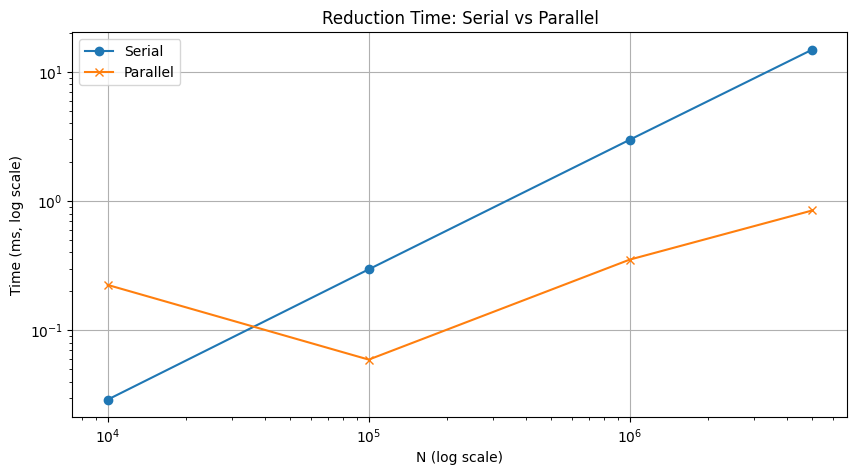

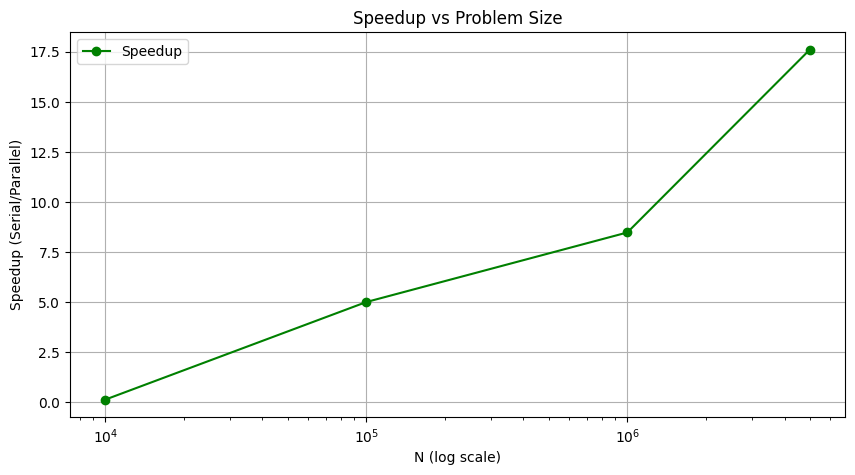

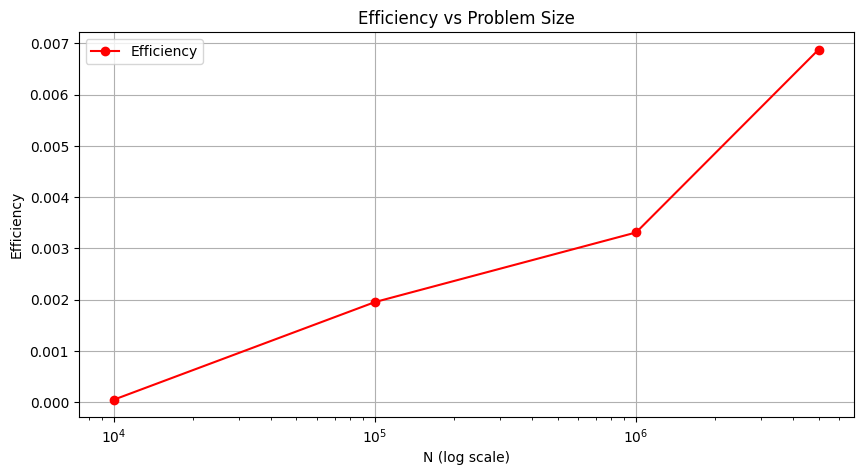

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("result.txt")
print("Execution Results:")
print(df)

# Time graph
plt.figure(figsize=(10, 5))
plt.plot(df.N, df.SERIAL, label="Serial", marker='o')
plt.plot(df.N, df.PARALLEL, label="Parallel", marker='x')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("N (log scale)")
plt.ylabel("Time (ms, log scale)")
plt.title("Reduction Time: Serial vs Parallel")
plt.legend()
plt.grid(True)
plt.show()

# Speedup
plt.figure(figsize=(10, 5))
plt.plot(df.N, df.SPEEDUP, label="Speedup", marker='o', color='green')
plt.xscale('log')
plt.xlabel("N (log scale)")
plt.ylabel("Speedup (Serial/Parallel)")
plt.title("Speedup vs Problem Size")
plt.legend()
plt.grid(True)
plt.show()

# Efficiency graph
plt.figure(figsize=(10, 5))
plt.plot(df.N, df.EFFICIENCY, label="Efficiency", marker='o', color='red')
plt.xscale('log')
plt.xlabel("N (log scale)")
plt.ylabel("Efficiency")
plt.title("Efficiency vs Problem Size")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
%%writefile HPC_REDUCTION.cu
#include <iostream>
#include <vector>
#include <cuda_runtime.h>
#include <chrono>
#include <fstream>

__global__ void sum_reduction(float* d_out, float* d_in, int n) {
    extern __shared__ float sdata[];
    unsigned int tid = threadIdx.x;
    unsigned int i = blockIdx.x * blockDim.x + threadIdx.x;

    sdata[tid] = (i < n) ? d_in[i] : 0;
    __syncthreads();

    for (unsigned int s = blockDim.x / 2; s > 0; s >>= 1) {
        if (tid < s)
            sdata[tid] += sdata[tid + s];
        __syncthreads();
    }

    if (tid == 0)
        d_out[blockIdx.x] = sdata[0];
}

// -------- FULL REDUCTION (IMPORTANT FIX) --------
float gpu_sum(float* d_in, int n) {
    int threads = 256;
    int blocks = (n + threads - 1) / threads;

    float *d_out;
    cudaMalloc(&d_out, blocks * sizeof(float));

    sum_reduction<<<blocks, threads, threads * sizeof(float)>>>(d_out, d_in, n);
    cudaDeviceSynchronize();

    // Copy partial sums to CPU
    std::vector<float> h_out(blocks);
    cudaMemcpy(h_out.data(), d_out, blocks * sizeof(float), cudaMemcpyDeviceToHost);

    float final_sum = 0;
    for (int i = 0; i < blocks; i++)
        final_sum += h_out[i];

    cudaFree(d_out);
    return final_sum;
}

// -------- TEST FUNCTION --------
void run_test(int n, std::ofstream& outfile) {
    size_t bytes = n * sizeof(float);
    std::vector<float> h_in(n, 1.0f);

    float *d_in;
    cudaMalloc(&d_in, bytes);
    cudaMemcpy(d_in, h_in.data(), bytes, cudaMemcpyHostToDevice);

    // -------- SERIAL --------
    float h_sum_cpu = 0;
    auto start_s = std::chrono::high_resolution_clock::now();
    for (int i = 0; i < n; i++)
        h_sum_cpu += h_in[i];
    auto end_s = std::chrono::high_resolution_clock::now();
    double time_s = std::chrono::duration<double, std::milli>(end_s - start_s).count();

    // -------- PARALLEL --------
    auto start_p = std::chrono::high_resolution_clock::now();
    float h_sum_gpu = gpu_sum(d_in, n);
    auto end_p = std::chrono::high_resolution_clock::now();
    double time_p = std::chrono::duration<double, std::milli>(end_p - start_p).count();

    int cores = 2560; // T4 GPU cores

    double speedup = time_s / time_p;
    double efficiency = speedup / cores;

    std::cout << "N=" << n
              << " CPU=" << h_sum_cpu
              << " GPU=" << h_sum_gpu
              << " Speedup=" << speedup << std::endl;

    outfile << n << ","
            << time_s << ","
            << time_p << ","
            << speedup << ","
            << efficiency << std::endl;

    cudaFree(d_in);
}

// -------- MAIN --------
int main() {
    std::ofstream outfile("result.txt");
    outfile << "N,SERIAL,PARALLEL,SPEEDUP,EFFICIENCY\n";

    int sizes[] = {10000, 100000, 1000000, 5000000};

    for (int n : sizes)
        run_test(n, outfile);

    outfile.close();

    return 0;
}

Overwriting HPC_REDUCTION.cu


In [ ]:
!nvcc HPC_REDUCTION.cu -o reduction && ./reduction

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
N=10000 CPU=10000 GPU=10000 Speedup=0.12935
N=100000 CPU=100000 GPU=100000 Speedup=5.00189
N=1000000 CPU=1e+06 GPU=1e+06 Speedup=8.47611
N=5000000 CPU=5e+06 GPU=5e+06 Speedup=17.6054
